In [20]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import tensorflow as tf
import time
import tensorflow as tf
import tensorflow.python.keras
import matplotlib.pyplot as plt


In [21]:
from keras.applications import VGG16
from tensorflow import keras
from tensorflow.keras.layers import Flatten, Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import plot_model
from glob import glob
from tensorflow.keras.optimizers import Adam

In [22]:
IMAGE_SIZE = [224,224]

In [23]:
# Create InceptionV3 Layer
vgg = VGG16(include_top=False,weights='imagenet',input_shape=IMAGE_SIZE + [3])
for layer in vgg.layers:
  layer.trainable = False

In [24]:
# we will use the glob to see how many outputs / labels there are
folders = glob('./plantvillage/*')

In [25]:
folders

['./plantvillage\\Tomato___Bacterial_spot',
 './plantvillage\\Tomato___Early_blight',
 './plantvillage\\Tomato___healthy',
 './plantvillage\\Tomato___Late_blight',
 './plantvillage\\Tomato___Leaf_Mold',
 './plantvillage\\Tomato___Septoria_leaf_spot',
 './plantvillage\\Tomato___Spider_mites Two-spotted_spider_mite',
 './plantvillage\\Tomato___Target_Spot',
 './plantvillage\\Tomato___Tomato_mosaic_virus',
 './plantvillage\\Tomato___Tomato_Yellow_Leaf_Curl_Virus']

In [26]:
# Add Flatten and Dense in last layers
x = GlobalAveragePooling2D()(vgg.output)
x = Dropout(0.5)(x)
prediction = Dense(len(folders),activation='softmax')(x)

In [27]:
model = Model(inputs=vgg.input,outputs = prediction)
plot_model(model)

You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.


In [28]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,719,818 (56.15 MB)

 Trainable params: 5,130 (20.04 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [29]:
# Compile the model that we have created with adam and the loss is categorical_crossentropy because the classification is more than 2 classes
model.compile(
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [ ]:
# Then use the CustomImageDataGenerator instead of ImageDataGenerator
train_datagen = ImageDataGenerator(
    validation_split=0.2,
    rescale=1./255,
    rotation_range=10,           # Very small rotations
    width_shift_range=0.05,      # Minimal shifts
    height_shift_range=0.05,
    shear_range=0.05,
    zoom_range=0.1,              # Small zoom
    horizontal_flip=True,
    fill_mode='nearest'
)


val_datagen = ImageDataGenerator(validation_split=0.2, rescale=1./255)
test_datagen = ImageDataGenerator(validation_split=0.2, rescale=1./255)

In [31]:
# Load training and validation data using tf.data.Dataset
training_set = train_datagen.flow_from_directory(
    './plantvillage/',
    target_size=(224, 224),
    batch_size=8,
    class_mode='categorical',  # Make sure this is set to categorical
    subset='training',
    shuffle = True
)

val_set = val_datagen.flow_from_directory(
    './plantvillage/',
    target_size=(224, 224),
    batch_size=8,
    class_mode='categorical',  # Make sure this is set to categorical
    subset='validation'
)

test_dataset = test_datagen.flow_from_directory(
    './plantvillage/',
    target_size=(224, 224),
    batch_size = 8,
    class_mode = 'categorical',
    shuffle = False

)


Found 10288 images belonging to 10 classes.
Found 2567 images belonging to 10 classes.
Found 12855 images belonging to 10 classes.


In [32]:
print(training_set)
print(val_set)

In [33]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6)

In [34]:
tic = time.perf_counter()
history = model.fit(training_set,
                    steps_per_epoch=len(training_set),
                    validation_data=val_set,
                    validation_steps=len(val_set),
                    epochs=40, callbacks=[early_stopping, reduce_lr])
# time
toc = time.perf_counter()
model.save('vgg16_test.keras')


Epoch 1/40
  18/1286 ━━━━━━━━━━━━━━━━━━━━ 39:02 2s/step - accuracy: 0.2353 - loss: 2.2947

KeyboardInterrupt: 

In [ ]:
print("Total Time:{}".format(round((toc-tic)/60,2)))

Total Time:1190.84


In [1]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

plt.plot(loss, label='train_loss')
plt.plot(val_loss,label = 'val_loss')
plt.legend()
plt.title("Train_loss: {:.4f}".format(history.history['loss'][-1]) +
          "\nValidation_loss: {:.4f}".format(history.history['val_loss'][-1]))
plt.savefig('vgg16_loss.png', dpi=150, bbox_inches='tight')
plt.show()

plt.plot(acc, label='train_acc')
plt.plot(val_acc,label = 'val_acc')
plt.title("Train_accuracy:{:.4f}".format(max(history.history['accuracy']))+
         "\nValidation_accuracy:{:.4f}".format(max(history.history['val_accuracy'])))
plt.legend()
plt.savefig('vgg16_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

NameError: name 'history' is not defined

In [ ]:
scores = model.evaluate(test_dataset)

1607/1607 ━━━━━━━━━━━━━━━━━━━━ 2793s 2s/step - accuracy: 0.9789 - loss: 0.0850


In [ ]:
y_pred = model.predict(test_dataset)    

1607/1607 ━━━━━━━━━━━━━━━━━━━━ 3129s 2s/step


In [ ]:
y_predict = np.argmax(y_pred,axis=1)
y_predict

array([0, 0, 0, ..., 9, 9, 9], dtype=int64)

In [ ]:
y_true = test_dataset.classes
y_true

array([0, 0, 0, ..., 9, 9, 9])

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
class_name = ['Tomato_Bacterial_spot','Tomato_Early_blight','Tomato_Late_blight','Tomato_Leaf_Mold','Tomato_Septoria_leaf_spot','Tomato_Spider_mites_Two_spotted_spider_mite','Tomato__Target_Spot','Tomato__Tomato_YellowLeaf__Curl_Virus','Tomato__Tomato_mosaic_virus','Tomato_healthy']

In [ ]:
print(classification_report(y_true,y_predict,target_names = class_name))

                                             precision    recall  f1-score   support

                      Tomato_Bacterial_spot       0.96      0.96      0.96        28
                        Tomato_Early_blight       0.97      0.96      0.97       800
                         Tomato_Late_blight       0.98      0.98      0.98      1527
                           Tomato_Leaf_Mold       0.98      0.97      0.98       761
                  Tomato_Septoria_leaf_spot       0.99      0.99      0.99      1417
Tomato_Spider_mites_Two_spotted_spider_mite       0.97      0.99      0.98      1341
                        Tomato__Target_Spot       0.97      0.98      0.97      1123
      Tomato__Tomato_YellowLeaf__Curl_Virus       1.00      1.00      1.00      4286
                Tomato__Tomato_mosaic_virus       1.00      0.99      1.00       299
                             Tomato_healthy       0.99      1.00      1.00      1273

                                   accuracy                    

In [ ]:
import seaborn as sns

In [ ]:
cm = confusion_matrix(y_true,y_predict)
cm

array([[  27,    0,    1,    0,    0,    0,    0,    0,    0,    0],
       [   0,  771,    9,    5,    1,    5,    7,    1,    0,    1],
       [   0,   14, 1497,    1,    8,    1,    3,    0,    0,    3],
       [   0,    2,    6,  737,    3,    8,    5,    0,    0,    0],
       [   0,    2,    4,    2, 1402,    1,    4,    0,    0,    2],
       [   0,    1,    1,    1,    0, 1323,   14,    0,    0,    1],
       [   0,    1,    1,    0,    1,   17, 1101,    0,    0,    2],
       [   1,    5,    1,    2,    2,    3,    5, 4267,    0,    0],
       [   0,    1,    0,    1,    0,    0,    0,    0,  297,    0],
       [   0,    0,    0,    0,    0,    0,    0,    0,    0, 1273]],
      dtype=int64)

In [ ]:
cm_normalized = np.round(cm/np.sum(cm,axis=1).reshape(-1,1),2)
print(cm_normalized)

[[0.96 0.   0.04 0.   0.   0.   0.   0.   0.   0.  ]
 [0.   0.96 0.01 0.01 0.   0.01 0.01 0.   0.   0.  ]
 [0.   0.01 0.98 0.   0.01 0.   0.   0.   0.   0.  ]
 [0.   0.   0.01 0.97 0.   0.01 0.01 0.   0.   0.  ]
 [0.   0.   0.   0.   0.99 0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.   0.99 0.01 0.   0.   0.  ]
 [0.   0.   0.   0.   0.   0.02 0.98 0.   0.   0.  ]
 [0.   0.   0.   0.   0.   0.   0.   1.   0.   0.  ]
 [0.   0.   0.   0.   0.   0.   0.   0.   0.99 0.  ]
 [0.   0.   0.   0.   0.   0.   0.   0.   0.   1.  ]]


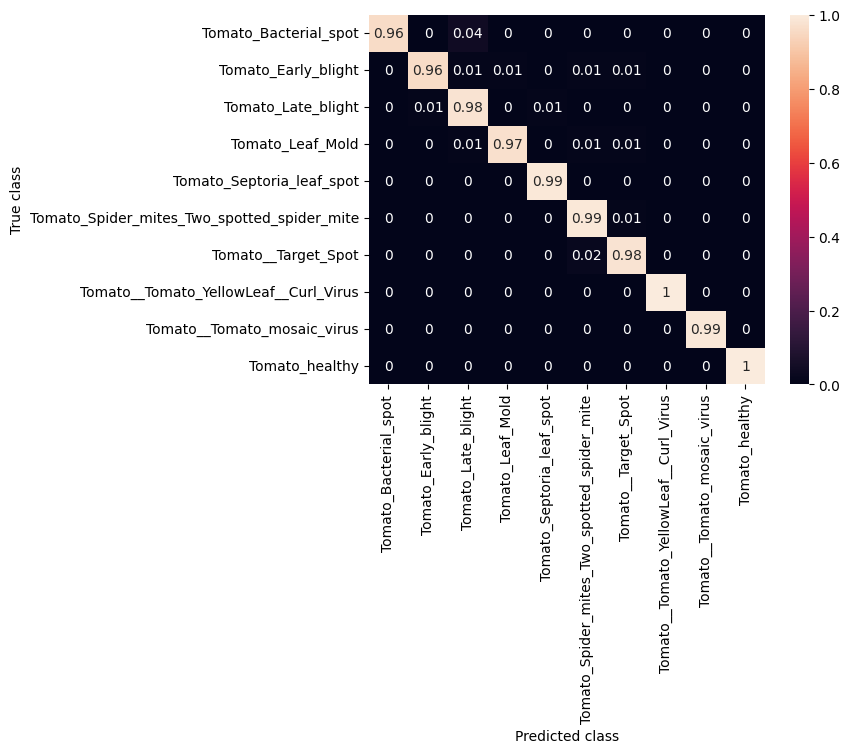

In [ ]:
sns.heatmap(cm_normalized, annot=True,xticklabels=class_name, yticklabels=class_name,)
plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.savefig('vgg16_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
import pickle
# Save the history object to a file
with open('history_vgg16.pkl', 'wb') as file:
    pickle.dump(history.history, file)